In [41]:
import pandas as pd

df_artists_final = pd.read_csv(
    'df_artists_final.csv',
    index_col=0
)
df_artists_final = df_artists_final.reset_index()

print(df_artists_final.shape)
print(df_artists_final.columns.tolist())

(759, 27)
['years_through_first_top_20_hit', '#_of_charting_songs_through_first_top_20_hit', 'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_Blues', 'artist_genre_Classical', 'artist_genre_Country/Americana', 'artist_genre_Easy Listening/Vocal', 'artist_genre_Electronic/Dance', 'artist_genre_Experimental/Avant-Garde', 'artist_genre_Folk', 'artist_genre_Gospel/Christian/Religious', 'artist_genre_Hip Hop/Rap', 'artist_genre_Jazz', 'artist_genre_Latin', 'artist_genre_Metal', 'artist_genre_Pop', 'artist_genre_Punk/Hardcore', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Reggae/Caribbean', 'artist_genre_Rock', 'artist_genre_World Music', 'artist_genre_unknown', '#_of_genres_artist', 'harmonic_closeness_centrality_top20_rolling5', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', 'top_20_hitmaker']


## Model

In [42]:
import pandas as pd

df_artists_final = pd.read_csv(
    'df_artists_final.csv',
    index_col=0
)
df_artists_final = df_artists_final.reset_index()

print(df_artists_final.shape)
print(df_artists_final.columns.tolist())


(759, 27)
['years_through_first_top_20_hit', '#_of_charting_songs_through_first_top_20_hit', 'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_Blues', 'artist_genre_Classical', 'artist_genre_Country/Americana', 'artist_genre_Easy Listening/Vocal', 'artist_genre_Electronic/Dance', 'artist_genre_Experimental/Avant-Garde', 'artist_genre_Folk', 'artist_genre_Gospel/Christian/Religious', 'artist_genre_Hip Hop/Rap', 'artist_genre_Jazz', 'artist_genre_Latin', 'artist_genre_Metal', 'artist_genre_Pop', 'artist_genre_Punk/Hardcore', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Reggae/Caribbean', 'artist_genre_Rock', 'artist_genre_World Music', 'artist_genre_unknown', '#_of_genres_artist', 'harmonic_closeness_centrality_top20_rolling5', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', 'top_20_hitmaker']


In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from catboost import CatBoostClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve
import optuna
from optuna.samplers import TPESampler
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)


In [44]:
# Separate features and target
X = df_artists_final.drop(columns=['top_20_hitmaker'])
y = df_artists_final['top_20_hitmaker']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print('')
print('y value counts:')
print(y.value_counts())
print('')
print('y class balance:')
print(y.value_counts(normalize=True).round(3))


X shape: (759, 26)
y shape: (759,)

y value counts:
top_20_hitmaker
0.0    431
1.0    328
Name: count, dtype: int64

y class balance:
top_20_hitmaker
0.0    0.568
1.0    0.432
Name: proportion, dtype: float64


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}')
print(f'Test:  {X_test.shape}')


Train: (607, 26)
Test:  (152, 26)


In [46]:
# CatBoost does not natively accept NaN values — unlike XGBoost.
# We impute with column medians, fitting only on the training set to prevent data leakage.

imputer = SimpleImputer(strategy='median')
X_train_clean = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_clean = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f'NaN in train: {X_train_clean.isna().sum().sum()}')
print(f'NaN in test:  {X_test_clean.isna().sum().sum()}')


NaN in train: 0
NaN in test:  0


In [47]:
# Baseline comparison: Dummy classifier vs CatBoost with default parameters.
# 5-fold stratified CV to preserve class balance across folds.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'neg_log_loss']

models_baseline = {
    'Dummy':    DummyClassifier(strategy='stratified', random_state=42),
    'CatBoost': CatBoostClassifier(n_estimators=100, random_state=42, verbose=0),
}

baseline_results = []
for name, model in models_baseline.items():
    cv = cross_validate(model, X_train_clean, y_train, cv=skf,
                        scoring=scoring, return_train_score=True)
    baseline_results.append({
        'Model':           name,
        'Accuracy':        cv['test_accuracy'].mean(),
        'Precision':       cv['test_precision'].mean(),
        'Recall':          cv['test_recall'].mean(),
        'F1':              cv['test_f1'].mean(),
        'ROC-AUC (CV)':    cv['test_roc_auc'].mean(),
        'ROC-AUC (Train)': cv['train_roc_auc'].mean(),
        'Overfit Gap':     cv['train_roc_auc'].mean() - cv['test_roc_auc'].mean(),
        'Log Loss':        -cv['test_neg_log_loss'].mean(),
    })

df_baseline = pd.DataFrame(baseline_results).set_index('Model').round(3)
print(df_baseline)


          Accuracy  Precision  Recall     F1  ROC-AUC (CV)  ROC-AUC (Train)  \
Model                                                                         
Dummy        0.522      0.444   0.427  0.436         0.511            0.486   
CatBoost     0.687      0.657   0.588  0.619         0.763            0.956   

          Overfit Gap  Log Loss  
Model                            
Dummy          -0.025    17.220  
CatBoost        0.193     0.577  


In [ ]:
# Hyperparameter tuning with penalized Optuna (lambda=0.3).
# Objective: AUC - lambda * overfit_gap.
# This penalizes overfitting while still rewarding predictive performance,
# replacing the two-stage RandomizedSearchCV approach used in ml_sandbox_16.
# lambda=0.3 means: willing to give up 0.01 AUC to reduce the gap by 0.033.

lam = 0.3

def make_objective(X, y, lam):
    def objective(trial):
        params = {
            'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
            'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'depth':           trial.suggest_int('depth', 3, 6),
            'l2_leaf_reg':     trial.suggest_float('l2_leaf_reg', 1, 100, log=True),
            'random_strength': trial.suggest_float('random_strength', 0.1, 10, log=True),
            'border_count':    trial.suggest_categorical('border_count', [64, 128, 254]),
            'random_state':    42,
            'verbose':         0,
        }
        fold_train_auc, fold_val_auc = [], []
        for train_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
            cb = CatBoostClassifier(**params)
            cb.fit(X_tr, y_tr)
            fold_val_auc.append(roc_auc_score(y_val, cb.predict_proba(X_val)[:, 1]))
            fold_train_auc.append(roc_auc_score(y_tr, cb.predict_proba(X_tr)[:, 1]))
        val_auc = np.mean(fold_val_auc)
        gap = np.mean(fold_train_auc) - val_auc
        return val_auc - lam * gap
    return objective

def cv_evaluate(X, y, params, skf):
    fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        cb = CatBoostClassifier(**params, random_state=42, verbose=0)
        cb.fit(X_tr, y_tr)
        proba    = cb.predict_proba(X_val)[:, 1]
        proba_tr = cb.predict_proba(X_tr)[:, 1]
        fold_val_auc.append(roc_auc_score(y_val, proba))
        fold_train_auc.append(roc_auc_score(y_tr, proba_tr))
        fold_logloss.append(log_loss(y_val, proba))
        fold_brier.append(brier_score_loss(y_val, proba))
    return {
        'CV AUC':      np.mean(fold_val_auc),
        'Train AUC':   np.mean(fold_train_auc),
        'Overfit Gap': np.mean(fold_train_auc) - np.mean(fold_val_auc),
        'Logloss':     np.mean(fold_logloss),
        'BrierScore':  np.mean(fold_brier),
    }

study_full = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_full.optimize(make_objective(X_train_clean, y_train, lam), n_trials=100, show_progress_bar=True)

best_params_full = study_full.best_params
res_full = cv_evaluate(X_train_clean, y_train, best_params_full, skf)
cv_auc   = res_full['CV AUC']
gap_full = res_full['Overfit Gap']

print(f'Best params: {best_params_full}')
print(f'CV AUC:      {cv_auc:.4f}')
print(f'Train AUC:   {res_full["Train AUC"]:.4f}')
print(f'Overfit Gap: {gap_full:.4f}')
print(f'Logloss:     {res_full["Logloss"]:.4f}')
print(f'BrierScore:  {res_full["BrierScore"]:.4f}')

# Optuna optimization history and hyperparameter importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
trial_vals = [t.value for t in study_full.trials]
axes[0].plot(trial_vals, color='steelblue', alpha=0.5, linewidth=1)
axes[0].plot(np.maximum.accumulate(trial_vals), color='darkblue', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Penalized Score (AUC - 0.3 * Gap)')
axes[0].set_title('Optuna Optimization History')
axes[0].legend()
axes[0].grid(True)
importances = optuna.importance.get_param_importances(study_full)
axes[1].barh(list(importances.keys()), list(importances.values()), color='steelblue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importance (Optuna)')
axes[1].grid(True)
plt.tight_layout()
plt.show()


  0%|          | 0/100 [00:00<?, ?it/s]

ROC-AUC (Test):  0.7674
Log Loss:        0.5720
Brier Score:     0.1939
Accuracy:        0.7368
F1:              0.6667
Overfit Gap:     0.0281

              precision    recall  f1-score   support

         0.0       0.73      0.84      0.78        86
         1.0       0.74      0.61      0.67        66

    accuracy                           0.74       152
   macro avg       0.74      0.72      0.72       152
weighted avg       0.74      0.74      0.73       152



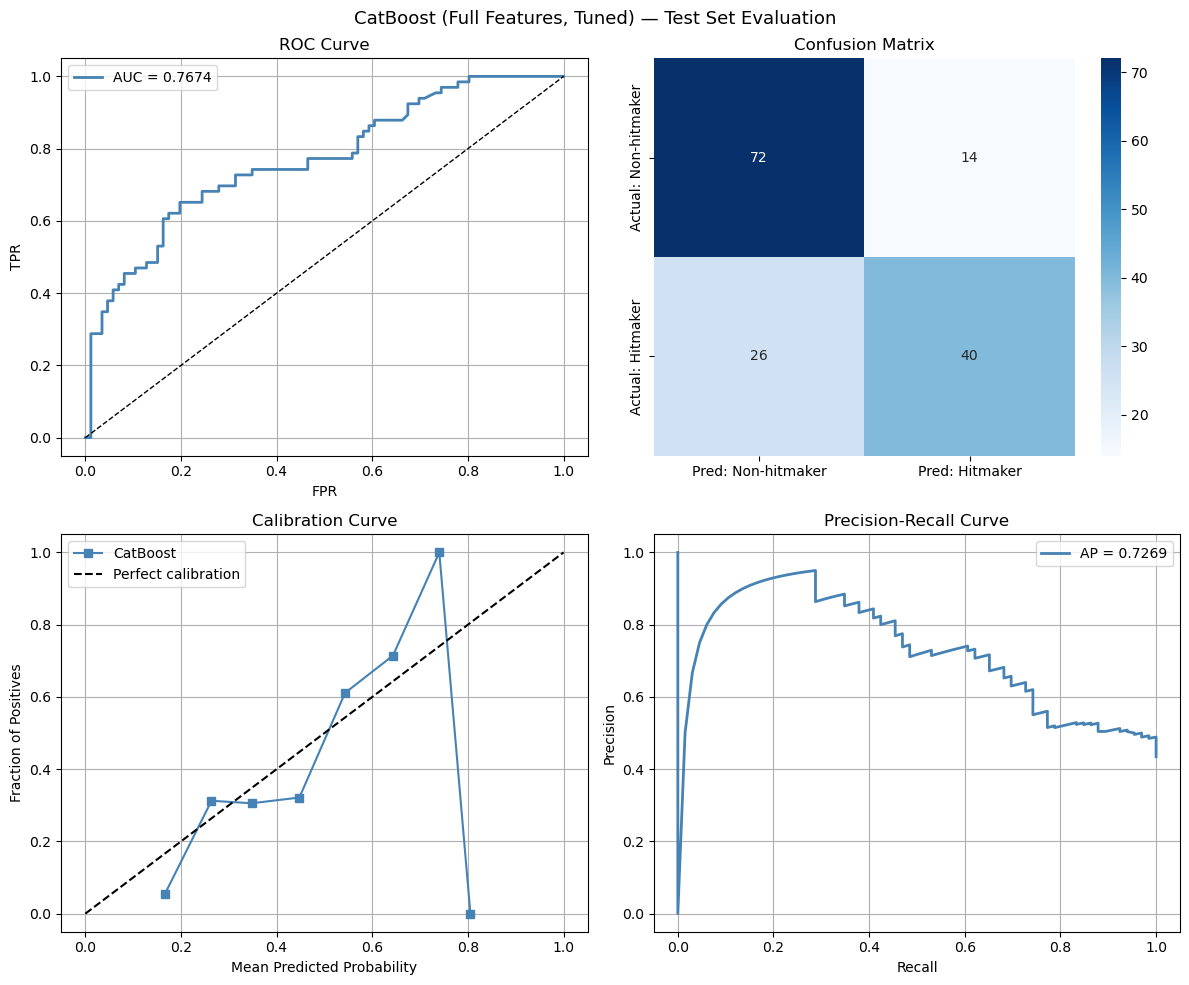

In [ ]:
# Fit tuned model on full training set and evaluate on test set.
# Also produce ROC curve, confusion matrix, calibration curve, and PR curve.

cb_full = CatBoostClassifier(**best_params_full, random_state=42, verbose=0)
cb_full.fit(X_train_clean, y_train)

y_proba       = cb_full.predict_proba(X_test_clean)[:, 1]
y_pred        = cb_full.predict(X_test_clean)
y_proba_train = cb_full.predict_proba(X_train_clean)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

test_auc_full  = roc_auc_score(y_test, y_proba)
train_auc_full = roc_auc_score(y_train, y_proba_train)
gap_test_full  = train_auc_full - test_auc_full

print(f'ROC-AUC (Test):  {test_auc_full:.4f}')
print(f'Log Loss:        {log_loss(y_test, y_proba):.4f}')
print(f'Brier Score:     {brier_score_loss(y_test, y_proba):.4f}')
print(f'Accuracy:        {accuracy_score(y_test, y_pred):.4f}')
print(f'F1:              {f1_score(y_test, y_pred):.4f}')
print(f'Overfit Gap:     {gap_test_full:.4f}')
print('')
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0, 0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {test_auc_full:.4f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].set_xlabel('FPR')
axes[0, 0].set_ylabel('TPR')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend()
axes[0, 0].grid(True)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=['Pred: Non-hitmaker', 'Pred: Hitmaker'],
            yticklabels=['Actual: Non-hitmaker', 'Actual: Hitmaker'])
axes[0, 1].set_title('Confusion Matrix')

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
axes[1, 0].plot(prob_pred, prob_true, 's-', color='steelblue', label='CatBoost')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
axes[1, 0].set_xlabel('Mean Predicted Probability')
axes[1, 0].set_ylabel('Fraction of Positives')
axes[1, 0].set_title('Calibration Curve')
axes[1, 0].legend()
axes[1, 0].grid(True)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[1, 1].plot(recall_vals, precision_vals, color='steelblue', lw=2, label=f'AP = {ap:.4f}')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision-Recall Curve')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.suptitle('CatBoost (Full Features, Tuned) — Test Set Evaluation', fontsize=13)
plt.tight_layout()
plt.show()


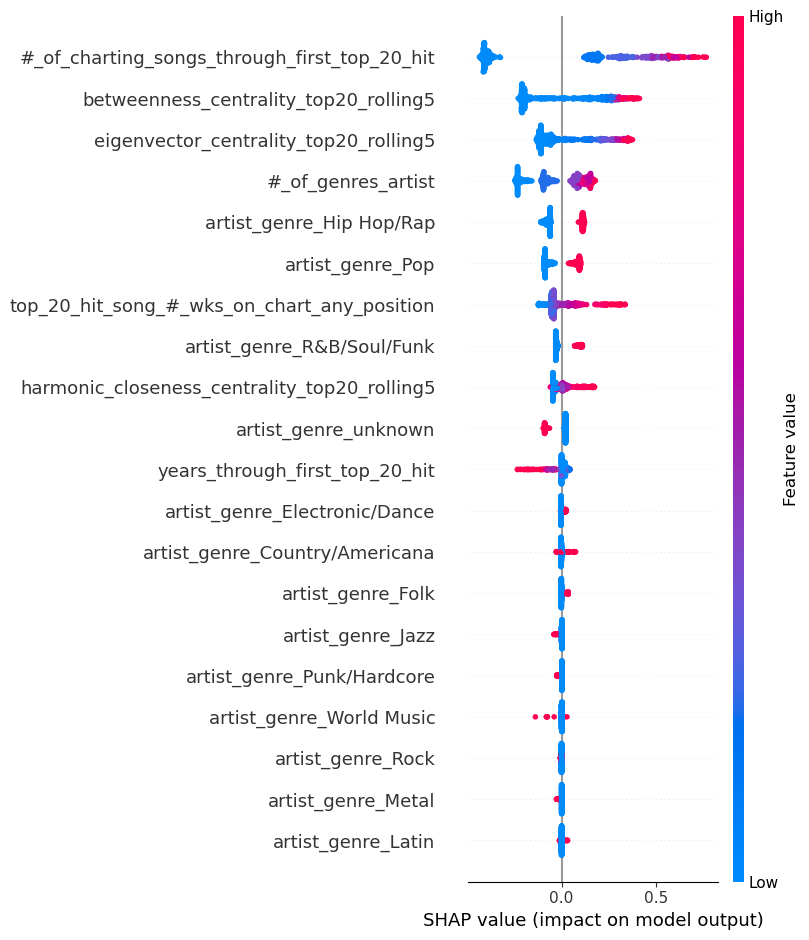

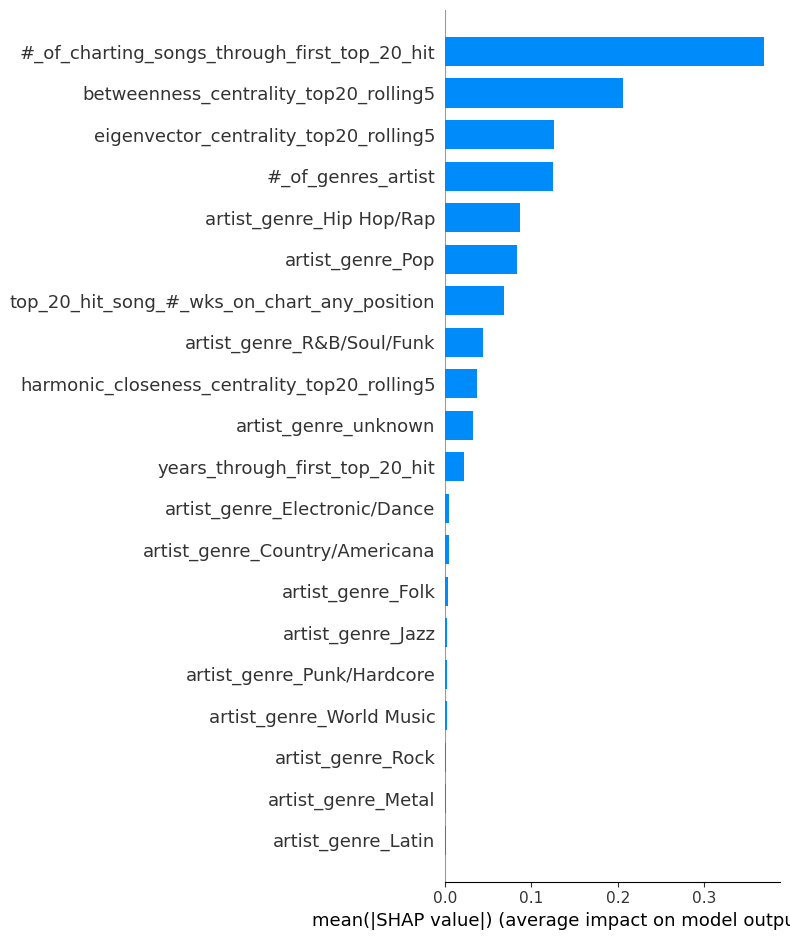

In [ ]:
# SHAP analysis on tuned full-feature model.
# Beeswarm shows direction and magnitude of each feature's impact.
# Bar chart shows mean absolute importance.

explainer_full = shap.TreeExplainer(cb_full)
shap_values_full = explainer_full.shap_values(X_train_clean)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_full, X_train_clean, show=True)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_full, X_train_clean, plot_type='bar', show=True)


#### Feature contribution analysis to see which features can be dropped

Baseline (all features)                             AUC: 0.7608  Gap: 0.0399
---------------------------------------------------------------------------
Drop [years_through_first_top_20_hit               ]  AUC: 0.7549 (-0.0059)  Gap: 0.0424 (+0.0025)
Drop [#_of_charting_songs_through_first_top_20_hit ]  AUC: 0.7251 (-0.0357)  Gap: 0.0433 (+0.0035)
Drop [top_20_hit_song_#_wks_on_chart_any_position  ]  AUC: 0.7593 (-0.0015)  Gap: 0.0373 (-0.0026)
Drop [artist_genre_Blues                           ]  AUC: 0.7579 (-0.0029)  Gap: 0.0411 (+0.0012)
Drop [artist_genre_Classical                       ]  AUC: 0.7569 (-0.0039)  Gap: 0.0428 (+0.0030)
Drop [artist_genre_Country/Americana               ]  AUC: 0.7581 (-0.0027)  Gap: 0.0419 (+0.0020)
Drop [artist_genre_Easy Listening/Vocal            ]  AUC: 0.7572 (-0.0036)  Gap: 0.0409 (+0.0011)
Drop [artist_genre_Electronic/Dance                ]  AUC: 0.7577 (-0.0031)  Gap: 0.0417 (+0.0018)
Drop [artist_genre_Experimental/Avant-Garde        ]  A

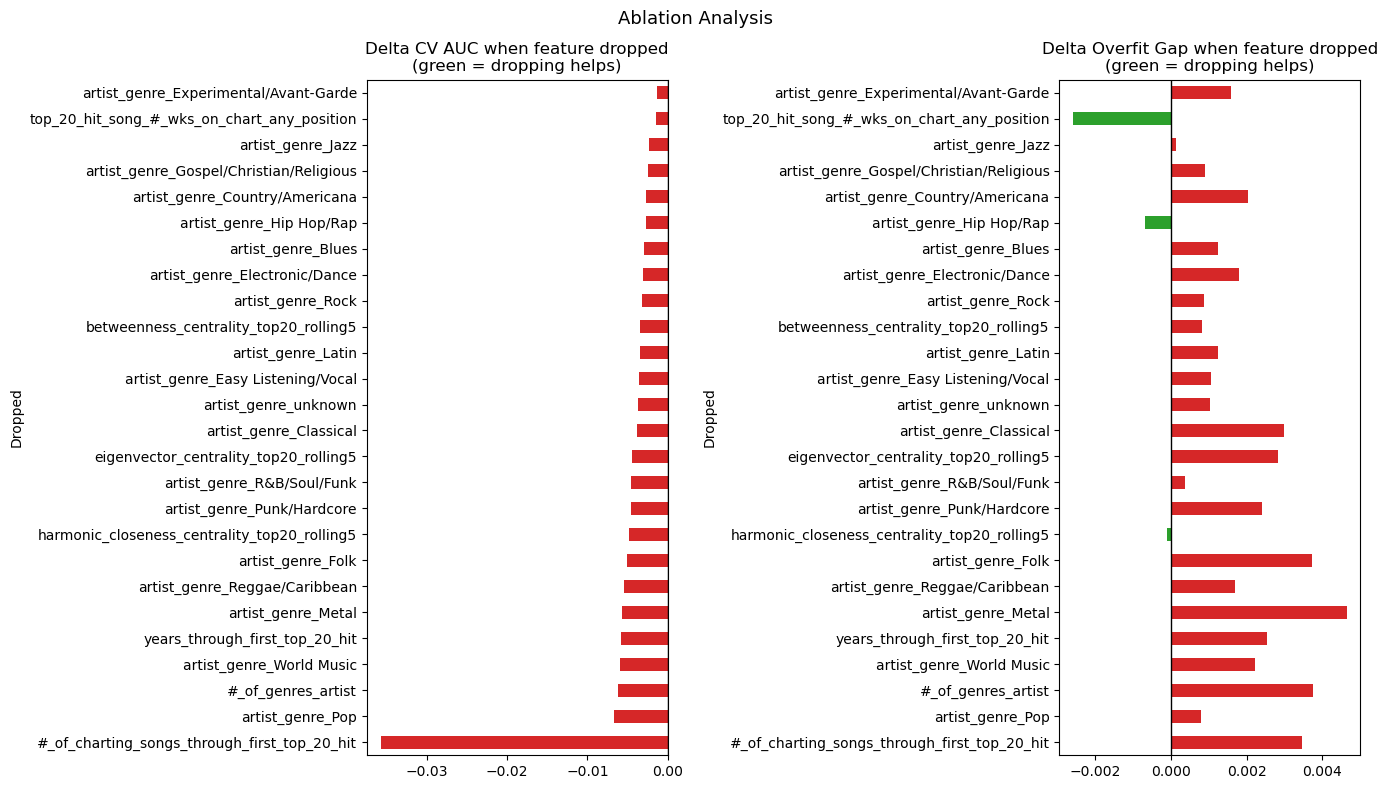

In [ ]:
# Ablation analysis: drop each feature one at a time and measure the impact
# on CV AUC and overfit gap. Features with near-zero or positive AUC delta
# when dropped are candidates for removal — they add noise, not signal.

def evaluate_features(X, y, params, skf):
    fold_train_auc, fold_val_auc = [], []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        cb = CatBoostClassifier(**params, random_state=42, verbose=0)
        cb.fit(X_tr, y_tr)
        fold_val_auc.append(roc_auc_score(y_val, cb.predict_proba(X_val)[:, 1]))
        fold_train_auc.append(roc_auc_score(y_tr, cb.predict_proba(X_tr)[:, 1]))
    return np.mean(fold_val_auc), np.mean(fold_train_auc) - np.mean(fold_val_auc)

baseline_auc, baseline_gap = evaluate_features(X_train_clean, y_train, best_params_full, skf)
print(f'{"Baseline (all features)":50s}  AUC: {baseline_auc:.4f}  Gap: {baseline_gap:.4f}')
print('-' * 75)

ablation_results = []
for feature in X_train_clean.columns:
    X_abl = X_train_clean.drop(columns=[feature])
    auc, gap = evaluate_features(X_abl, y_train, best_params_full, skf)
    delta_auc = auc - baseline_auc
    delta_gap = gap - baseline_gap
    ablation_results.append({
        'Dropped': feature,
        'CV AUC':  auc,
        'Delta AUC': delta_auc,
        'Gap':     gap,
        'Delta Gap': delta_gap,
    })
    print(f'Drop [{feature[:45]:45s}]  AUC: {auc:.4f} ({delta_auc:+.4f})  Gap: {gap:.4f} ({delta_gap:+.4f})')

df_ablation = pd.DataFrame(ablation_results).set_index('Dropped').sort_values('Delta AUC')

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
auc_colors = ['#2ca02c' if v >= 0 else '#d62728' for v in df_ablation['Delta AUC']]
gap_colors = ['#2ca02c' if v <= 0 else '#d62728' for v in df_ablation['Delta Gap']]
df_ablation['Delta AUC'].plot(kind='barh', ax=axes[0], color=auc_colors)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Delta CV AUC when feature dropped\n(green = dropping helps)')
df_ablation['Delta Gap'].plot(kind='barh', ax=axes[1], color=gap_colors)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Delta Overfit Gap when feature dropped\n(green = dropping helps)')
plt.suptitle('Ablation Analysis', fontsize=13)
plt.tight_layout()
plt.show()


Features before consolidation: 26
Features after consolidation:  12

Consolidated feature list:
['years_through_first_top_20_hit', '#_of_charting_songs_through_first_top_20_hit', 'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_Hip Hop/Rap', 'artist_genre_Pop', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Rock', '#_of_genres_artist', 'harmonic_closeness_centrality_top20_rolling5', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', 'artist_genre_other']


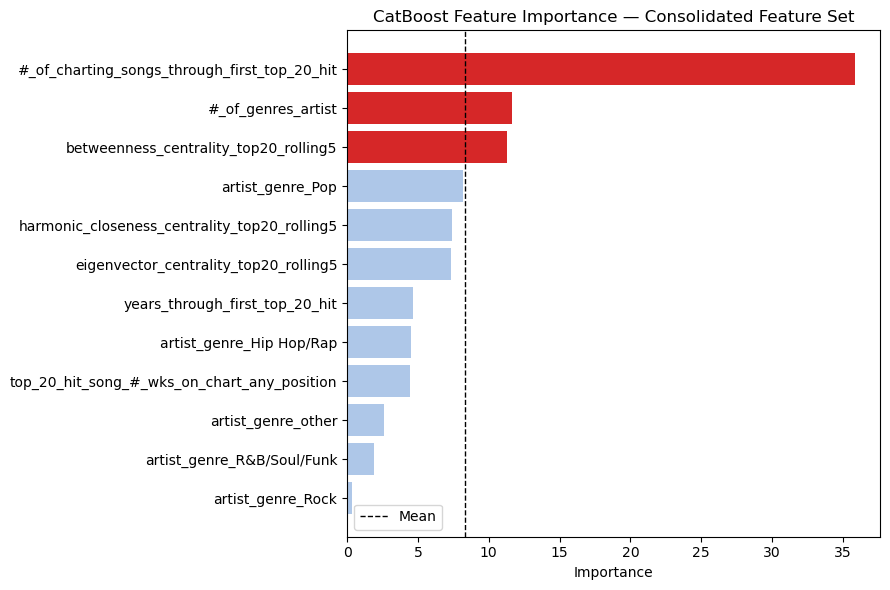


Feature importance order:
                                     Feature  Importance
#_of_charting_songs_through_first_top_20_hit   35.836486
                          #_of_genres_artist   11.625263
       betweenness_centrality_top20_rolling5   11.289766
                            artist_genre_Pop    8.151074
harmonic_closeness_centrality_top20_rolling5    7.379300
       eigenvector_centrality_top20_rolling5    7.347041
              years_through_first_top_20_hit    4.648224
                    artist_genre_Hip Hop/Rap    4.507206
 top_20_hit_song_#_wks_on_chart_any_position    4.422090
                          artist_genre_other    2.579616
                  artist_genre_R&B/Soul/Funk    1.858394
                           artist_genre_Rock    0.355540


In [ ]:
# Genre consolidation: following ml_sandbox_17_compare_final_xgboost_tuning, we consolidate 14 low-signal genre dummies
# into a single artist_genre_other feature, keeping 4 high-signal genres separate.
# This reduces feature noise while preserving genre signal as a consolidated binary flag.

high_signal_genres = [
    'artist_genre_Pop',
    'artist_genre_Rock',
    'artist_genre_Hip Hop/Rap',
    'artist_genre_R&B/Soul/Funk',
]
all_genre_cols    = [c for c in X_train_clean.columns if c.startswith('artist_genre_')]
low_signal_genres = [c for c in all_genre_cols if c not in high_signal_genres]

X_train_cons = X_train_clean.drop(columns=low_signal_genres).copy()
X_train_cons['artist_genre_other'] = (X_train_clean[low_signal_genres].sum(axis=1) > 0).astype(int)
X_test_cons  = X_test_clean.drop(columns=low_signal_genres).copy()
X_test_cons['artist_genre_other']  = (X_test_clean[low_signal_genres].sum(axis=1) > 0).astype(int)

print(f'Features before consolidation: {X_train_clean.shape[1]}')
print(f'Features after consolidation:  {X_train_cons.shape[1]}')
print('')
print('Consolidated feature list:')
print(X_train_cons.columns.tolist())

# Feature importance on consolidated set — used to guide forward selection order
cb_cons = CatBoostClassifier(**best_params_full, random_state=42, verbose=0)
cb_cons.fit(X_train_cons, y_train)
feat_imp_cons = cb_cons.get_feature_importance(prettified=True)
feat_imp_cons.columns = ['Feature', 'Importance']
feat_imp_cons = feat_imp_cons.sort_values('Importance', ascending=False)
feature_order = feat_imp_cons['Feature'].tolist()

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp_plot = feat_imp_cons.sort_values('Importance', ascending=True)
colors = ['#d62728' if v >= feat_imp_cons['Importance'].quantile(0.75) else '#aec7e8'
          for v in feat_imp_plot['Importance']]
ax.barh(feat_imp_plot['Feature'], feat_imp_plot['Importance'], color=colors)
ax.axvline(feat_imp_cons['Importance'].mean(), color='black', linestyle='--', linewidth=1, label='Mean')
ax.set_xlabel('Importance')
ax.set_title('CatBoost Feature Importance — Consolidated Feature Set')
ax.legend()
plt.tight_layout()
plt.show()

print('')
print('Feature importance order:')
print(feat_imp_cons.to_string(index=False))


### Re-tuning CatBoost with genre consolidation and forward feature selection

n= 3  +[betweenness_centrality_top20_rolling5   ]  AUC: 0.7473  Gap: 0.0268
n= 4  +[artist_genre_Pop                        ]  AUC: 0.7443  Gap: 0.0321
n= 5  +[harmonic_closeness_centrality_top20_roll]  AUC: 0.7526  Gap: 0.0374
n= 6  +[eigenvector_centrality_top20_rolling5   ]  AUC: 0.7536  Gap: 0.0394
n= 7  +[years_through_first_top_20_hit          ]  AUC: 0.7608  Gap: 0.0376
n= 8  +[artist_genre_Hip Hop/Rap                ]  AUC: 0.7598  Gap: 0.0402
n= 9  +[top_20_hit_song_#_wks_on_chart_any_posit]  AUC: 0.7602  Gap: 0.0436
n=10  +[artist_genre_other                      ]  AUC: 0.7608  Gap: 0.0448
n=11  +[artist_genre_R&B/Soul/Funk              ]  AUC: 0.7611  Gap: 0.0449
n=12  +[artist_genre_Rock                       ]  AUC: 0.7616  Gap: 0.0444


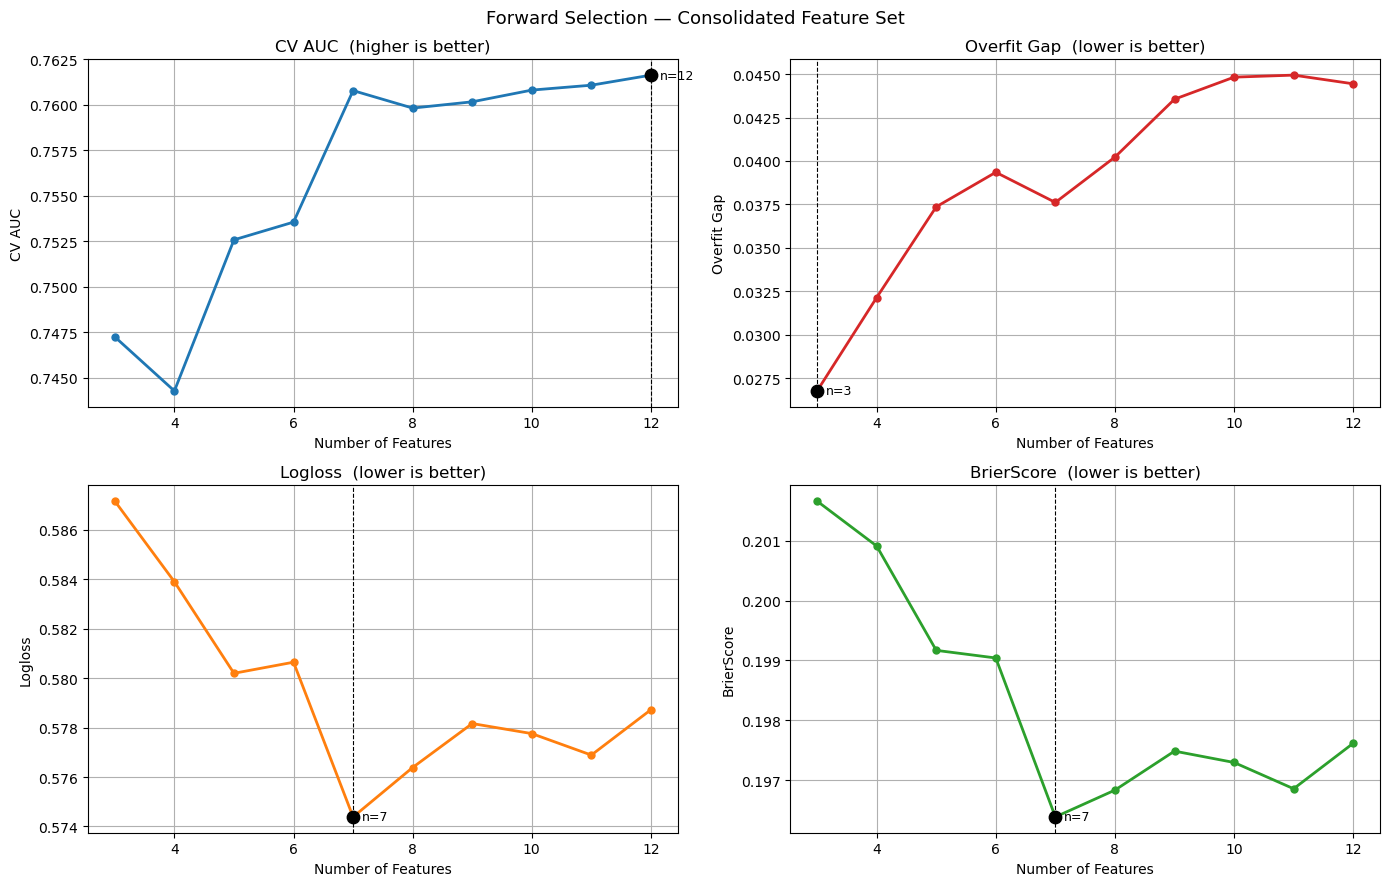

In [ ]:
# Forward feature selection: start with top 3 features (by importance) and add one at a time.
# Track CV AUC, overfit gap, Logloss, and BrierScore to find the optimal feature count.
# The goal is to find the smallest set that maximizes performance while keeping the gap low.

sel_results = []
for n_feats in range(3, len(feature_order) + 1):
    feats  = feature_order[:n_feats]
    X_sub  = X_train_cons[feats]
    fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []
    for train_idx, val_idx in skf.split(X_sub, y_train):
        X_tr, X_val = X_sub.iloc[train_idx], X_sub.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        cb = CatBoostClassifier(**best_params_full, random_state=42, verbose=0)
        cb.fit(X_tr, y_tr)
        proba    = cb.predict_proba(X_val)[:, 1]
        proba_tr = cb.predict_proba(X_tr)[:, 1]
        fold_val_auc.append(roc_auc_score(y_val, proba))
        fold_train_auc.append(roc_auc_score(y_tr, proba_tr))
        fold_logloss.append(log_loss(y_val, proba))
        fold_brier.append(brier_score_loss(y_val, proba))
    val_auc   = np.mean(fold_val_auc)
    train_auc = np.mean(fold_train_auc)
    sel_results.append({
        'n_features':  n_feats,
        'last_added':  feature_order[n_feats - 1],
        'CV AUC':      val_auc,
        'Train AUC':   train_auc,
        'Overfit Gap': train_auc - val_auc,
        'Logloss':     np.mean(fold_logloss),
        'BrierScore':  np.mean(fold_brier),
    })
    print(f'n={n_feats:2d}  +[{feature_order[n_feats-1][:40]:40s}]  AUC: {val_auc:.4f}  Gap: {train_auc-val_auc:.4f}')

df_sel = pd.DataFrame(sel_results).set_index('n_features')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (metric, color, better) in zip(axes.flat, [
    ('CV AUC',      '#1f77b4', 'higher'),
    ('Overfit Gap', '#d62728', 'lower'),
    ('Logloss',     '#ff7f0e', 'lower'),
    ('BrierScore',  '#2ca02c', 'lower'),
]):
    ax.plot(df_sel.index, df_sel[metric], 'o-', color=color, linewidth=2, markersize=5)
    best_n   = df_sel[metric].idxmax() if better == 'higher' else df_sel[metric].idxmin()
    best_val = df_sel[metric][best_n]
    ax.scatter([best_n], [best_val], color='black', zorder=5, s=80)
    ax.axvline(best_n, color='black', linestyle='--', linewidth=0.8)
    ax.text(best_n + 0.15, best_val, f'n={best_n}', fontsize=9, va='center')
    ax.set_xlabel('Number of Features')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}  ({"higher" if better == "higher" else "lower"} is better)')
    ax.grid(True)
plt.suptitle('Forward Selection — Consolidated Feature Set', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# Re-tune with penalized Optuna (lambda=0.3) on two candidate feature subsets.
# n=7 maximises CV AUC with the lowest gap; n=12 uses all consolidated features.
# Re-tuning each subset separately lets hyperparameters adapt to the new feature space.

candidate_ns = [7, 12]

optuna_studies   = {}   # study objects keyed by n
best_params_by_n = {}   # best Optuna params keyed by n
cv_results_by_n  = {}   # cv_evaluate results keyed by n
X_train_by_n     = {n: X_train_cons[feature_order[:n]] for n in candidate_ns}
X_test_by_n      = {n: X_test_cons[feature_order[:n]]  for n in candidate_ns}

for n in candidate_ns:
    print(f'\n--- Optuna: n={n} features ---')
    print('  Features:', feature_order[:n])
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(make_objective(X_train_by_n[n], y_train, lam),
                   n_trials=100, show_progress_bar=True)
    optuna_studies[n]   = study
    best_params_by_n[n] = study.best_params
    cv_results_by_n[n]  = cv_evaluate(X_train_by_n[n], y_train, study.best_params, skf)
    res = cv_results_by_n[n]
    print(f'  CV AUC:      {res["CV AUC"]:.4f}')
    print(f'  Train AUC:   {res["Train AUC"]:.4f}')
    print(f'  Overfit Gap: {res["Overfit Gap"]:.4f}')
    print(f'  Logloss:     {res["Logloss"]:.4f}')
    print(f'  BrierScore:  {res["BrierScore"]:.4f}')

# Summary table across all candidates
print('\n--- CV Summary (all candidates) ---')
df_cv_summary = pd.DataFrame({
    n: cv_results_by_n[n] for n in candidate_ns
}).T.round(4)
df_cv_summary.index.name = 'n_features'
print(df_cv_summary.to_string())

# Set n=7 as default for final model analysis — change if desired based on results above
n_optimal     = 7
top_features  = feature_order[:n_optimal]
X_train_final = X_train_by_n[n_optimal]
X_test_final  = X_test_by_n[n_optimal]
best_params_final = best_params_by_n[n_optimal]



--- Optuna: n=7 features ---
  Features: ['#_of_charting_songs_through_first_top_20_hit', '#_of_genres_artist', 'betweenness_centrality_top20_rolling5', 'artist_genre_Pop', 'harmonic_closeness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', 'years_through_first_top_20_hit']


  0%|          | 0/100 [00:00<?, ?it/s]

  CV AUC:      0.7720
  Train AUC:   0.8171
  Overfit Gap: 0.0451
  Logloss:     0.5664
  BrierScore:  0.1931

--- Optuna: n=12 features ---
  Features: ['#_of_charting_songs_through_first_top_20_hit', '#_of_genres_artist', 'betweenness_centrality_top20_rolling5', 'artist_genre_Pop', 'harmonic_closeness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', 'years_through_first_top_20_hit', 'artist_genre_Hip Hop/Rap', 'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_other', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Rock']


  0%|          | 0/100 [00:00<?, ?it/s]

  CV AUC:      0.7609
  Train AUC:   0.7928
  Overfit Gap: 0.0319
  Logloss:     0.5840
  BrierScore:  0.1995

--- CV Summary (all candidates) ---
            CV AUC  Train AUC  Overfit Gap  Logloss  BrierScore
n_features                                                     
7           0.7720     0.8171       0.0451   0.5664      0.1931
12          0.7609     0.7928       0.0319   0.5840      0.1995


In [ ]:
# Compare all CatBoost candidates on the held-out test set.
# XGBoost results from ml_sandbox_17_compare_final_xgboost_tuning are included for direct comparison.
# All models are fit on the full training set and evaluated once on the test set.

def test_evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    proba_te = model.predict_proba(X_te)[:, 1]
    proba_tr = model.predict_proba(X_tr)[:, 1]
    return {
        'Test AUC':    roc_auc_score(y_te, proba_te),
        'Train AUC':   roc_auc_score(y_tr, proba_tr),
        'Overfit Gap': roc_auc_score(y_tr, proba_tr) - roc_auc_score(y_te, proba_te),
        'Logloss':     log_loss(y_te, proba_te),
        'BrierScore':  brier_score_loss(y_te, proba_te),
    }

candidates = {
    'CatBoost (all 26 features)': (
        CatBoostClassifier(**best_params_full, random_state=42, verbose=0),
        X_train_clean, X_test_clean
    ),
}
# Add all four Optuna-tuned subsets
for n in candidate_ns:
    candidates[f'CatBoost (consolidated n={n})'] = (
        CatBoostClassifier(**best_params_by_n[n], random_state=42, verbose=0),
        X_train_by_n[n], X_test_by_n[n]
    )

test_results = []
for name, (model, X_tr, X_te) in candidates.items():
    res = test_evaluate(model, X_tr, y_train, X_te, y_test)
    res['Model']      = name
    res['N Features'] = X_tr.shape[1]
    test_results.append(res)
    print(f'{name}: AUC={res["Test AUC"]:.4f}  Gap={res["Overfit Gap"]:.4f}  Logloss={res["Logloss"]:.4f}  Brier={res["BrierScore"]:.4f}')

# XGBoost (tight regularization) from ml_sandbox_17_compare_final_xgboost_tuning
test_results.append({
    'Model':       'XGBoost (ml_sandbox_17_compare)',
    'Test AUC':    0.757,
    'Train AUC':   0.771,
    'Overfit Gap': 0.015,
    'Logloss':     0.593,
    'BrierScore':  0.203,
    'N Features':  10,
})

df_comparison = pd.DataFrame(test_results).set_index('Model').round(4)
print('')
print('--- Final Comparison ---')
print(df_comparison[['Test AUC', 'Overfit Gap', 'Logloss', 'BrierScore', 'N Features']].to_string())

CatBoost (all 26 features): AUC=0.7674  Gap=0.0281  Logloss=0.5720  Brier=0.1939
CatBoost (consolidated n=7): AUC=0.7592  Gap=0.0524  Logloss=0.5764  Brier=0.1962
CatBoost (consolidated n=12): AUC=0.7661  Gap=0.0274  Logloss=0.5723  Brier=0.1940

--- Final Comparison ---
                                 Test AUC  Overfit Gap  Logloss  BrierScore  N Features
Model                                                                                  
CatBoost (all 26 features)         0.7674       0.0281   0.5720      0.1939          26
CatBoost (consolidated n=7)        0.7592       0.0524   0.5764      0.1962           7
CatBoost (consolidated n=12)       0.7661       0.0274   0.5723      0.1940          12
XGBoost (ml_sandbox_17_compare)    0.7570       0.0150   0.5930      0.2030          10


Take just n=12. Since n=7 already came from Optuna with λ=0.3 and gave gap=0.045. Running the three configs on n=12 gives the tight/mid/aggressive breakdown on the fuller feature set.

In [ ]:
# Three Optuna runs with different regularization strengths on n=12 features.
# Aggressive: complex model, low regularization
# Mid: balanced
# Tight: simple model, high regularization

from optuna.samplers import TPESampler

lam = 0.3  # same penalized objective throughout

def make_objective_constrained(X, y, lam, depth_range, lr_range, l2_range,
                                rs_range, min_leaf_range):
    def objective(trial):
        params = {
            'n_estimators':   trial.suggest_int('n_estimators', 50, 400),
            'learning_rate':  trial.suggest_float('learning_rate', *lr_range, log=True),
            'depth':          trial.suggest_int('depth', *depth_range),
            'l2_leaf_reg':    trial.suggest_float('l2_leaf_reg', *l2_range, log=True),
            'random_strength':trial.suggest_float('random_strength', *rs_range),
            'min_data_in_leaf':trial.suggest_int('min_data_in_leaf', *min_leaf_range),
            'border_count':   trial.suggest_int('border_count', 32, 254),
        }
        fold_train_auc, fold_val_auc = [], []
        for train_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
            model = CatBoostClassifier(**params, random_state=42, verbose=0)
            model.fit(X_tr, y_tr)
            fold_val_auc.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
            fold_train_auc.append(roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1]))
        val_auc = np.mean(fold_val_auc)
        gap     = np.mean(fold_train_auc) - val_auc
        return val_auc - lam * gap
    return objective

#                          depth   lr             l2_leaf_reg    random_str  min_leaf
configs = {
    'Aggressive': dict(depth_range=(4, 8),  lr_range=(0.01, 0.3),   l2_range=(0.1, 10),   rs_range=(0.1, 3),  min_leaf_range=(1, 5)),
    'Mid':        dict(depth_range=(3, 6),  lr_range=(0.005, 0.1),  l2_range=(1.0, 50),   rs_range=(1.0, 5),  min_leaf_range=(3, 15)),
    'Tight':      dict(depth_range=(3, 5),  lr_range=(0.005, 0.05), l2_range=(10.0, 200), rs_range=(2.0, 10), min_leaf_range=(5, 30)),
}

X_feat = X_train_by_n[12]
X_feat_test = X_test_by_n[12]

reg_studies, reg_params, reg_cv = {}, {}, {}

for name, cfg in configs.items():
    print(f'\n--- Optuna: {name} ---')
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(make_objective_constrained(X_feat, y_train, lam, **cfg),
                   n_trials=100, show_progress_bar=True)
    reg_studies[name] = study
    reg_params[name]  = study.best_params
    reg_cv[name]      = cv_evaluate(X_feat, y_train, study.best_params, skf)
    res = reg_cv[name]
    print(f'  CV AUC:      {res["CV AUC"]:.4f}')
    print(f'  Train AUC:   {res["Train AUC"]:.4f}')
    print(f'  Overfit Gap: {res["Overfit Gap"]:.4f}')
    print(f'  Logloss:     {res["Logloss"]:.4f}')
    print(f'  BrierScore:  {res["BrierScore"]:.4f}')

print('\n--- CV Summary ---')
df_reg = pd.DataFrame({k: reg_cv[k] for k in configs}).T.round(4)
df_reg.index.name = 'Regularization'
print(df_reg.to_string())

n_optimal         = 12
top_features      = feature_order[:n_optimal]
X_train_final     = X_train_by_n[n_optimal]
X_test_final      = X_test_by_n[n_optimal]
best_params_final = reg_params['Mid']



--- Optuna: Aggressive ---


  0%|          | 0/100 [00:00<?, ?it/s]

  CV AUC:      0.7642
  Train AUC:   0.8014
  Overfit Gap: 0.0373
  Logloss:     0.5863
  BrierScore:  0.2001

--- Optuna: Mid ---


  0%|          | 0/100 [00:00<?, ?it/s]

  CV AUC:      0.7637
  Train AUC:   0.7963
  Overfit Gap: 0.0326
  Logloss:     0.5857
  BrierScore:  0.1999

--- Optuna: Tight ---


  0%|          | 0/100 [00:00<?, ?it/s]

  CV AUC:      0.7640
  Train AUC:   0.8025
  Overfit Gap: 0.0385
  Logloss:     0.5769
  BrierScore:  0.1969

--- CV Summary ---
                CV AUC  Train AUC  Overfit Gap  Logloss  BrierScore
Regularization                                                     
Aggressive      0.7642     0.8014       0.0373   0.5863      0.2001
Mid             0.7637     0.7963       0.0326   0.5857      0.1999
Tight           0.7640     0.8025       0.0385   0.5769      0.1969


#### Deciding if trimming makes sense

#### Deciding if the centrality features are all necessary

In [ ]:
from itertools import combinations

centrality_feats = [
    'betweenness_centrality_top20_rolling5',
    'harmonic_closeness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5',
]

# All subsets: drop 0, 1, or 2 centrality features
drop_combos = [()] + list(combinations(centrality_feats, 1)) + list(combinations(centrality_feats, 2))

rows = []
for dropped in drop_combos:
    feats = [f for f in top_features if f not in dropped]
    res   = cv_evaluate(X_train_cons[feats], y_train, best_params_final, skf)
    rows.append({
        'Dropped':      ', '.join([f.replace('_centrality_top20_rolling5','') for f in dropped]) or 'none',
        'N feats':      len(feats),
        'CV AUC':       round(res['CV AUC'], 4),
        'Overfit Gap':  round(res['Overfit Gap'], 4),
        'Logloss':      round(res['Logloss'], 4),
        'BrierScore':   round(res['BrierScore'], 4),
    })

results_df = pd.DataFrame(rows).sort_values('CV AUC', ascending=False)
print(results_df.to_string(index=False))


                        Dropped  N feats  CV AUC  Overfit Gap  Logloss  BrierScore
                           none       12  0.7637       0.0326   0.5857      0.1999
                    betweenness       11  0.7562       0.0360   0.5926      0.2029
betweenness, harmonic_closeness       10  0.7550       0.0332   0.5904      0.2021
             harmonic_closeness       11  0.7541       0.0326   0.5936      0.2034
harmonic_closeness, eigenvector       10  0.7536       0.0337   0.5901      0.2020
       betweenness, eigenvector       10  0.7520       0.0350   0.5936      0.2034
                    eigenvector       11  0.7514       0.0384   0.5949      0.2039


Contrary to XGBoost, all three centrality features contribute, or at least there's a clear tradeoff in dropping

#### Deciding if dropping any genre features helps

In [ ]:
from itertools import combinations

genre_feats = [
    'artist_genre_Hip Hop/Rap',
    'artist_genre_other',
    'artist_genre_R&B/Soul/Funk',
    'artist_genre_Rock',
    'artist_genre_Pop'
]

drop_combos = [()] + list(combinations(genre_feats, 1)) + list(combinations(genre_feats, 2)) + [tuple(genre_feats)]

rows = []
for dropped in drop_combos:
    feats = [f for f in top_features if f not in dropped]
    res   = cv_evaluate(X_train_cons[feats], y_train, best_params_final, skf)
    rows.append({
        'Dropped':     ', '.join([f.replace('artist_genre_','') for f in dropped]) or 'none',
        'N feats':     len(feats),
        'CV AUC':      round(res['CV AUC'], 4),
        'Overfit Gap': round(res['Overfit Gap'], 4),
        'Logloss':     round(res['Logloss'], 4),
        'BrierScore':  round(res['BrierScore'], 4),
    })

results_genre = pd.DataFrame(rows).sort_values('CV AUC', ascending=False)
print(results_genre.to_string(index=False))


                                     Dropped  N feats  CV AUC  Overfit Gap  Logloss  BrierScore
                                        none       12  0.7637       0.0326   0.5857      0.1999
                                        Rock       11  0.7558       0.0348   0.5905      0.2020
                                 Hip Hop/Rap       11  0.7552       0.0351   0.5913      0.2024
                               R&B/Soul/Funk       11  0.7542       0.0360   0.5915      0.2025
                                       other       11  0.7541       0.0353   0.5913      0.2024
                           Hip Hop/Rap, Rock       10  0.7541       0.0343   0.5905      0.2021
                         R&B/Soul/Funk, Rock       10  0.7539       0.0359   0.5904      0.2021
                                 other, Rock       10  0.7534       0.0348   0.5913      0.2025
                                   Rock, Pop       10  0.7531       0.0313   0.5947      0.2038
                          Hip Hop/Rap, o

#### Final model analysis


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss, f1_score,
    precision_score, recall_score, accuracy_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve
import shap

model_final = CatBoostClassifier(**best_params_final, random_state=42, verbose=0)
model_final.fit(X_train_final, y_train)

y_pred        = model_final.predict(X_test_final)
y_proba       = model_final.predict_proba(X_test_final)[:, 1]
y_proba_train = model_final.predict_proba(X_train_final)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print('=' * 52)
print(f'FINAL MODEL — CatBoost (n={n_optimal}, Mid regularization)')
print('=' * 52)
print(f'  ROC-AUC  (CV):    {reg_cv["Mid"]["CV AUC"]:.3f}')
print(f'  ROC-AUC  (Train): {roc_auc_score(y_train, y_proba_train):.3f}')
print(f'  ROC-AUC  (Test):  {roc_auc_score(y_test,  y_proba):.3f}')
print(f'  Overfit Gap:      {roc_auc_score(y_train, y_proba_train) - roc_auc_score(y_test, y_proba):.3f}')
print(f'  Log Loss:         {log_loss(y_test, y_proba):.3f}')
print(f'  Brier Score:      {brier_score_loss(y_test, y_proba):.3f}')
print(f'  Accuracy:         {accuracy_score(y_test, y_pred):.3f}')
print(f'  Precision:        {precision_score(y_test, y_pred):.3f}')
print(f'  Recall:           {recall_score(y_test, y_pred):.3f}')
print(f'  F1:               {f1_score(y_test, y_pred):.3f}')
print(f'  TP={tp}  FP={fp}  FN={fn}  TN={tn}')
print()
print(classification_report(y_test, y_pred,
      target_names=['One-hit Wonder', 'Hitmaker']))


FINAL MODEL — CatBoost (n=12, Mid regularization)
  ROC-AUC  (CV):    0.764
  ROC-AUC  (Train): 0.791
  ROC-AUC  (Test):  0.770
  Overfit Gap:      0.022
  Log Loss:         0.576
  Brier Score:      0.195
  Accuracy:         0.704
  Precision:        0.706
  Recall:           0.545
  F1:               0.615
  TP=36  FP=15  FN=30  TN=71

                precision    recall  f1-score   support

One-hit Wonder       0.70      0.83      0.76        86
      Hitmaker       0.71      0.55      0.62        66

      accuracy                           0.70       152
     macro avg       0.70      0.69      0.69       152
  weighted avg       0.70      0.70      0.70       152



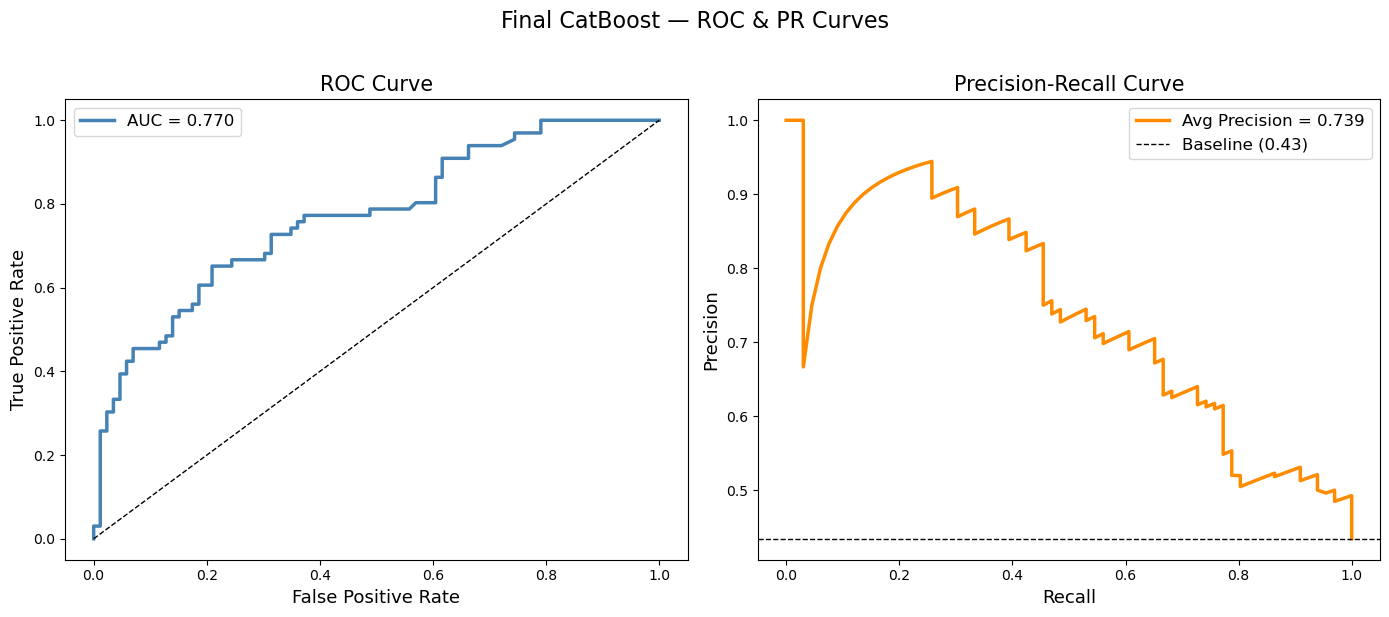

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='steelblue', lw=2.5,
             label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate', fontsize=13)
axes[0].set_ylabel('True Positive Rate', fontsize=13)
axes[0].set_title('ROC Curve', fontsize=15)
axes[0].legend(fontsize=12)

# PR
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[1].plot(rec, prec, color='darkorange', lw=2.5, label=f'Avg Precision = {ap:.3f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', lw=1,
                label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall', fontsize=13)
axes[1].set_ylabel('Precision', fontsize=13)
axes[1].set_title('Precision-Recall Curve', fontsize=15)
axes[1].legend(fontsize=12)

plt.suptitle('Final CatBoost — ROC & PR Curves', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


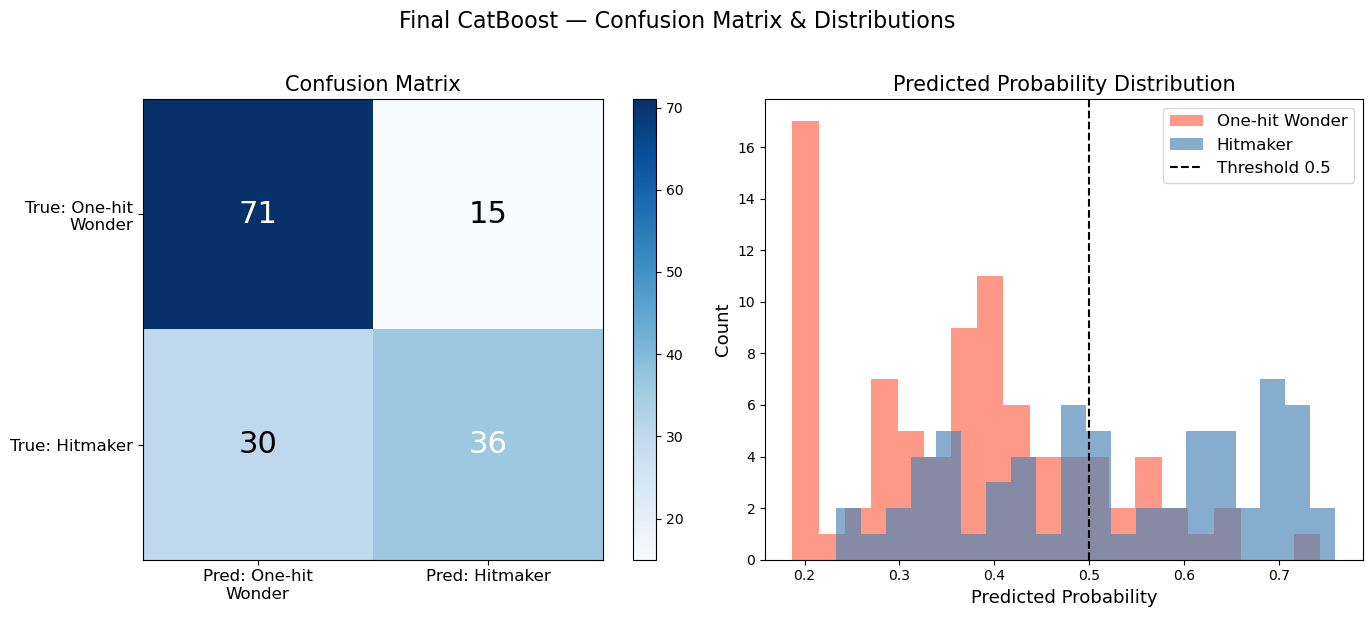

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Pred: One-hit\nWonder', 'Pred: Hitmaker'], fontsize=12)
axes[0].set_yticklabels(['True: One-hit\nWonder', 'True: Hitmaker'], fontsize=12)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center', fontsize=22,
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
axes[0].set_title('Confusion Matrix', fontsize=15)
plt.colorbar(im, ax=axes[0])

# Probability distributions
axes[1].hist(y_proba[y_test == 0], bins=20, alpha=0.65, color='tomato',
             label='One-hit Wonder')
axes[1].hist(y_proba[y_test == 1], bins=20, alpha=0.65, color='steelblue',
             label='Hitmaker')
axes[1].axvline(0.5, color='k', linestyle='--', lw=1.5, label='Threshold 0.5')
axes[1].set_xlabel('Predicted Probability', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].set_title('Predicted Probability Distribution', fontsize=15)
axes[1].legend(fontsize=12)

plt.suptitle('Final CatBoost — Confusion Matrix & Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


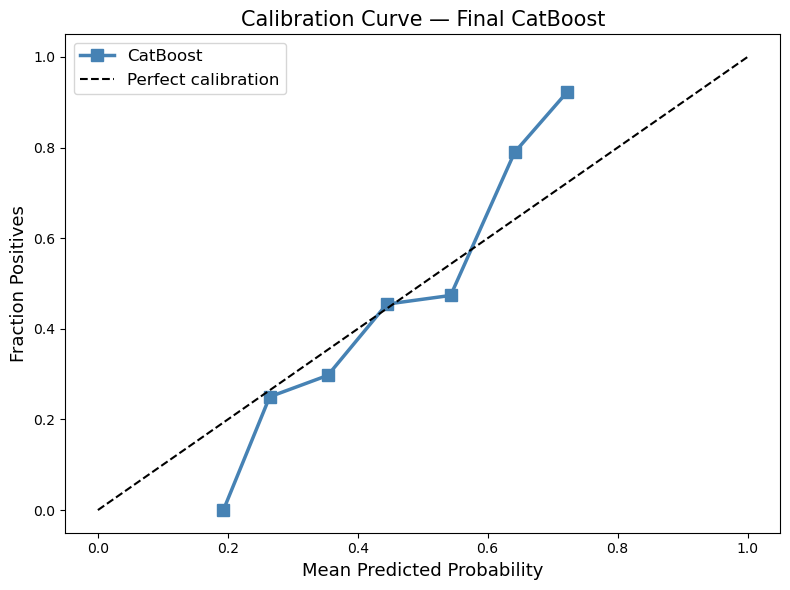

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
fraction_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)
ax.plot(mean_pred, fraction_pos, 's-', color='steelblue', lw=2.5,
        markersize=8, label='CatBoost')
ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability', fontsize=13)
ax.set_ylabel('Fraction Positives', fontsize=13)
ax.set_title('Calibration Curve — Final CatBoost', fontsize=15)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


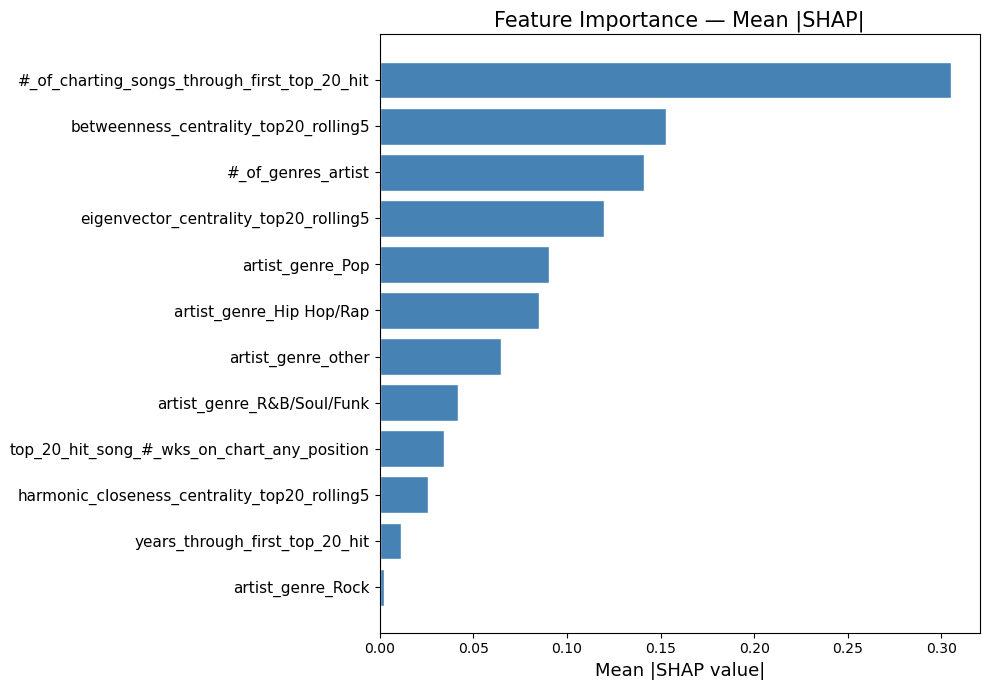

In [ ]:
explainer   = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test_final)

mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test_final.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(mean_abs_shap.index, mean_abs_shap.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Mean |SHAP value|', fontsize=13)
ax.set_title('Feature Importance — Mean |SHAP|', fontsize=15)
ax.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.show()


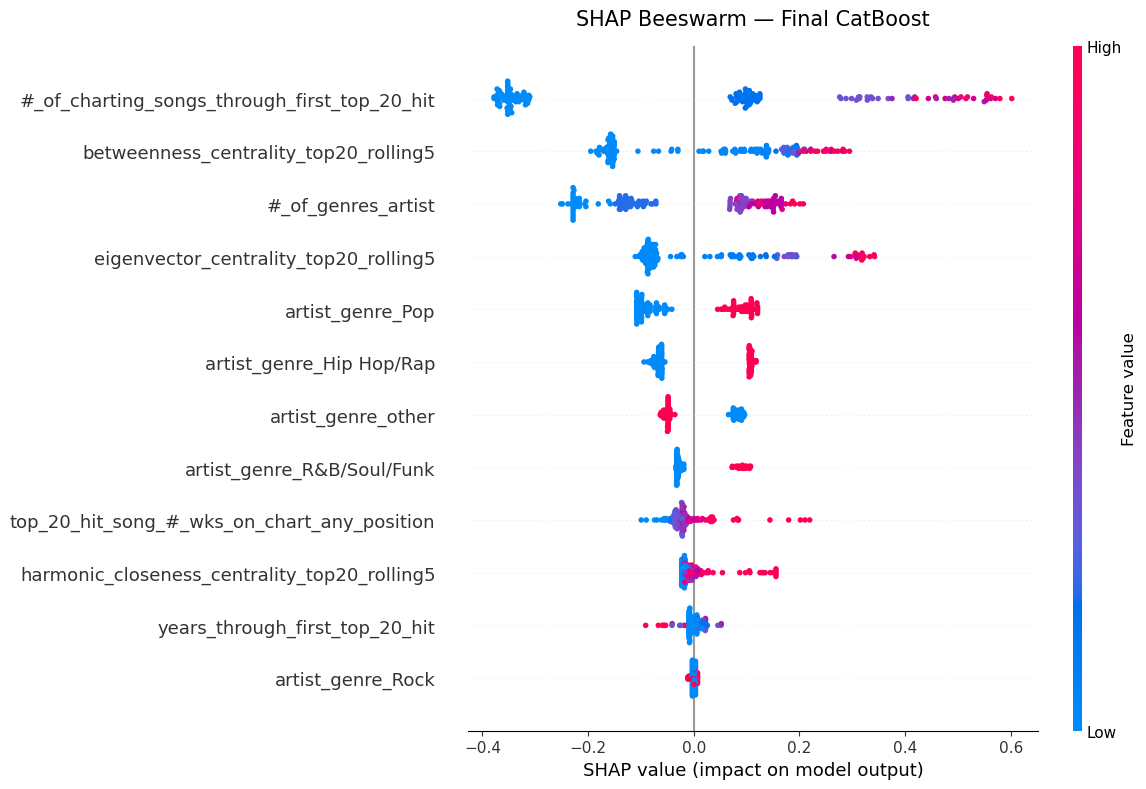

In [ ]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_final, show=False, plot_size=None)
plt.title('SHAP Beeswarm — Final CatBoost', fontsize=15, pad=15)
plt.tight_layout()
plt.show()


In [ ]:
shap_df      = pd.DataFrame(shap_values, columns=X_test_final.columns)
direction_df = pd.DataFrame({
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    'signed_corr':   [np.corrcoef(X_test_final.iloc[:, i], shap_df.iloc[:, i])[0,1]
                      for i in range(X_test_final.shape[1])]
}, index=X_test_final.columns).sort_values('mean_abs_shap', ascending=False)

direction_df['direction'] = direction_df['signed_corr'].apply(
    lambda r: '+ (higher → Hitmaker)' if r > 0 else '- (higher → One-hit Wonder)'
)

print('\n── SHAP Feature Directions ──')
print(direction_df[['mean_abs_shap', 'signed_corr', 'direction']].to_string())



── SHAP Feature Directions ──
                                              mean_abs_shap  signed_corr                    direction
#_of_charting_songs_through_first_top_20_hit       0.305298     0.732489        + (higher → Hitmaker)
betweenness_centrality_top20_rolling5              0.153062     0.511165        + (higher → Hitmaker)
#_of_genres_artist                                 0.141369     0.869670        + (higher → Hitmaker)
eigenvector_centrality_top20_rolling5              0.119564     0.808937        + (higher → Hitmaker)
artist_genre_Pop                                   0.090584     0.978882        + (higher → Hitmaker)
artist_genre_Hip Hop/Rap                           0.084846     0.997698        + (higher → Hitmaker)
artist_genre_other                                 0.064665    -0.996027  - (higher → One-hit Wonder)
artist_genre_R&B/Soul/Funk                         0.041692     0.993207        + (higher → Hitmaker)
top_20_hit_song_#_wks_on_chart_any_position        

#### Threshold tuning

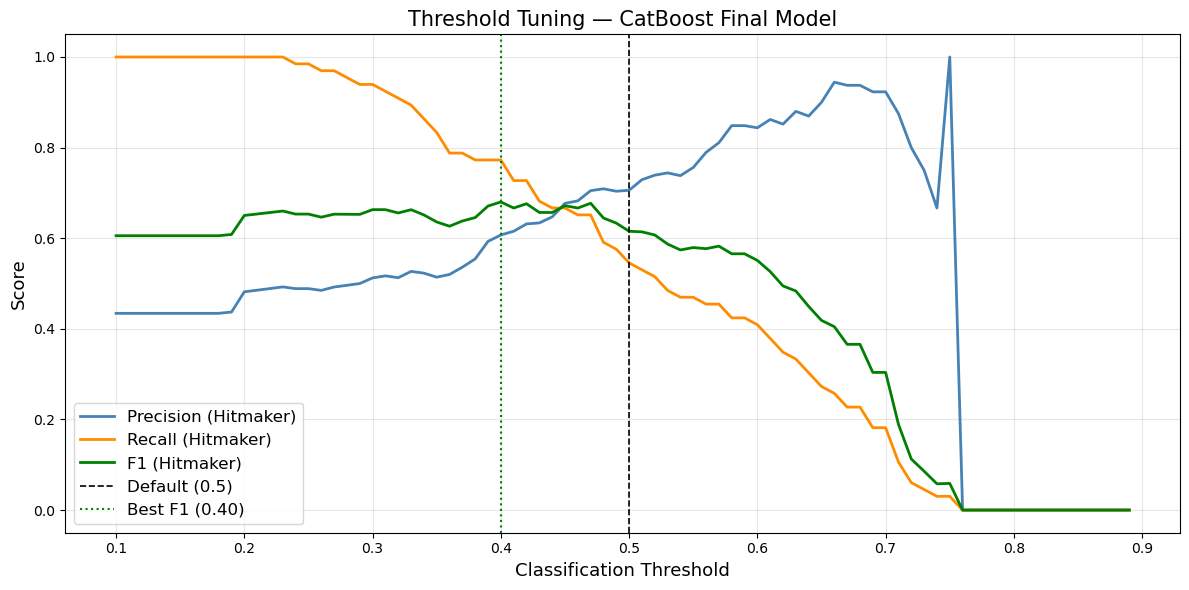


 Threshold  Precision   Recall       F1
------------------------------------------
      0.35      0.514    0.833    0.636
      0.40      0.607    0.773    0.680
      0.40      0.607    0.773    0.680
      0.45      0.677    0.667    0.672
      0.50      0.706    0.545    0.615


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.01)

precisions, recalls, f1s = [], [], []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

precisions = np.array(precisions)
recalls    = np.array(recalls)
f1s        = np.array(f1s)

best_f1_thresh = thresholds[np.argmax(f1s)]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds, precisions, label='Precision (Hitmaker)', color='steelblue',  lw=2)
ax.plot(thresholds, recalls,    label='Recall (Hitmaker)',    color='darkorange', lw=2)
ax.plot(thresholds, f1s,        label='F1 (Hitmaker)',        color='green',      lw=2)
ax.axvline(0.5,            color='k',      linestyle='--', lw=1.2, label='Default (0.5)')
ax.axvline(best_f1_thresh, color='green',  linestyle=':',  lw=1.5, label=f'Best F1 ({best_f1_thresh:.2f})')
ax.set_xlabel('Classification Threshold', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Threshold Tuning — CatBoost Final Model', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print stats at key thresholds
print(f'\n{"Threshold":>10} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 42)
for t in sorted(set([0.35, 0.40, 0.41, 0.42, 0.43, 0.44, 0.45, 0.50, best_f1_thresh])):
    y_pred_t = (y_proba >= t).astype(int)
    print(f'{t:>10.2f} {precision_score(y_test, y_pred_t):>10.3f} '
          f'{recall_score(y_test, y_pred_t):>8.3f} '
          f'{f1_score(y_test, y_pred_t):>8.3f}')


Threshold: 0.43
TP=47  FP=25  FN=19  TN=61

                precision    recall  f1-score   support

One-hit Wonder       0.76      0.71      0.73        86
      Hitmaker       0.65      0.71      0.68        66

      accuracy                           0.71       152
     macro avg       0.71      0.71      0.71       152
  weighted avg       0.71      0.71      0.71       152



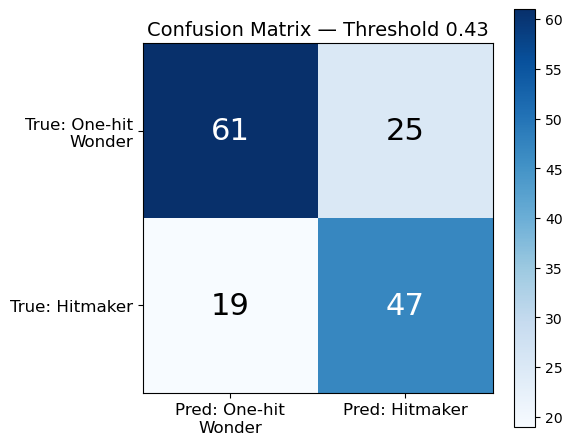

In [34]:
# Lock in threshold = 0.43
# Rationale: recall improves from 0.576 → 0.712 (+0.136), catching ~9 more hitmakers
# on the test set. Precision drops modestly from 0.731 → 0.653 (-0.078).
# For hitmaker prediction, missing a real hitmaker (FN) is costlier than a false alarm (FP),
# so the recall gain justifies the precision trade-off. F1 also improves: 0.644 → 0.681.

threshold = 0.43
y_pred_tuned = (y_proba >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tuned).ravel()

print(f'Threshold: {threshold}')
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')
print()
print(classification_report(y_test, y_pred_tuned,
      target_names=['One-hit Wonder', 'Hitmaker']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_tuned)
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred: One-hit\nWonder', 'Pred: Hitmaker'], fontsize=12)
ax.set_yticklabels(['True: One-hit\nWonder', 'True: Hitmaker'], fontsize=12)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=22,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_title(f'Confusion Matrix — Threshold {threshold}', fontsize=14)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
